In [83]:
import pandas as pd
import numpy as np

# Read data
df = pd.read_csv("../../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA.csv")
df = df.rename(columns={"index_nsa": "hpi"})
df.columns


/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_69117/4263314855.py:5: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA.csv")


Index(['Unnamed: 0', 'county_fips5', 'yr', 'hpi_change', 'hpi', 'state',
       'flood_frequency', 'flood_property_damage', 'flood_duration_hours',
       'heat_stress_index', 'drought_annual_mean_index', 'fire_frequency',
       'fire_size', 'deaths_hurricane', 'injuries_hurricane',
       'damage_hurricane', 'real_gdp', 'unemployment_rate', 'prop_rate',
       'county_fips', 'total_home_purchase', 'total_amt_purchase',
       'total_population'],
      dtype='object')

In [84]:
# Define hazard and financial predictors
climate_financial_vars = [
    "flood_frequency",
    "flood_property_damage",
    "flood_duration_hours",
    "heat_stress_index",
    "drought_annual_mean_index",
    "fire_frequency",
    "fire_size",
    "deaths_hurricane",
    "injuries_hurricane",
    "damage_hurricane",
    "real_gdp",
    "unemployment_rate",
    "prop_rate",
    "total_home_purchase",
    "total_amt_purchase",
    "total_population"
]

In [85]:
# Keep the columns of interest
columns_to_keep = ["county_fips5", "yr", "hpi", "flood_frequency", "flood_property_damage", "flood_duration_hours", "heat_stress_index",
"drought_annual_mean_index", "fire_frequency", "fire_size", "deaths_hurricane", "injuries_hurricane", "damage_hurricane", "real_gdp",
"unemployment_rate", "prop_rate", "total_home_purchase", "total_amt_purchase", "total_population"]
df = df[columns_to_keep]
df[climate_financial_vars] = df[climate_financial_vars].replace(["(NA)", "NA", ""], np.nan)

In [86]:
# Create lag 1 HPI
df = df.sort_values(["county_fips5", "yr"])
df["hpi_lag1"] = df.groupby("county_fips5")["hpi"].shift(1)
df_lagged = df.dropna(subset=["hpi_lag1"]).reset_index(drop=True)

# Standarize the variables with scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_lagged[climate_financial_vars])
df_scaled = pd.DataFrame(X_scaled, columns=climate_financial_vars, index=df_lagged.index)

df_lagged = pd.concat([df_lagged, df_scaled], axis=1)

In [87]:
import bambi as bmb
import arviz as az

# Create a copy for modeling
df_lagged_bayes = df_lagged.copy()
df_lagged_bayes = df_lagged_bayes.loc[
    :, ~df_lagged_bayes.columns.duplicated(keep="last")
]

# Double check everything is in scaled form
for col in climate_financial_vars:
    df_lagged_bayes[col] = df_scaled[col]

df_lagged_bayes = df_lagged_bayes.dropna().reset_index(drop=True)
df_lagged_bayes["hpi_lag1_scaled"] = StandardScaler().fit_transform(df_lagged_bayes[["hpi_lag1"]])

# Run the Bayesian model and output summary
formula_fe = "hpi ~ hpi_lag1_scaled + " + " + ".join(climate_financial_vars)
model_simple = bmb.Model(formula=formula_fe, data=df_lagged_bayes)
results_simple = model_simple.fit(draws=1000, tune=1000, chains=2, cores=1)
az.summary(results_simple, round_to=2)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, Intercept, hpi_lag1_scaled, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, deaths_hurricane, injuries_hurricane, damage_hurricane, real_gdp, unemployment_rate, prop_rate, total_home_purchase, total_amt_purchase, total_population]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 114 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,20.78,0.06,20.66,20.89,0.00,0.00,4239.48,1338.43,1.00
Intercept,268.47,0.09,268.32,268.64,0.00,0.00,2652.22,1663.81,1.00
hpi_lag1_scaled,182.29,0.10,182.09,182.47,0.00,0.00,2854.95,1582.18,1.00
flood_frequency,-0.16,0.10,-0.35,0.01,0.00,0.00,5602.62,1579.26,1.01
flood_property_damage,-0.07,0.09,-0.26,0.09,0.00,0.00,4688.84,1311.69,1.00
flood_duration_hours,-0.28,0.09,-0.45,-0.12,0.00,0.00,3385.12,1040.24,1.00
heat_stress_index,-0.11,0.10,-0.31,0.07,0.00,0.00,3302.20,1606.62,1.00
drought_annual_mean_index,-0.23,0.10,-0.41,-0.03,0.00,0.00,2724.88,1322.29,1.00
fire_frequency,0.66,0.10,0.47,0.84,0.00,0.00,2743.06,1464.45,1.00
fire_size,0.01,0.09,-0.16,0.17,0.00,0.00,3187.71,1553.02,1.00


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


<Axes: xlabel='hpi'>

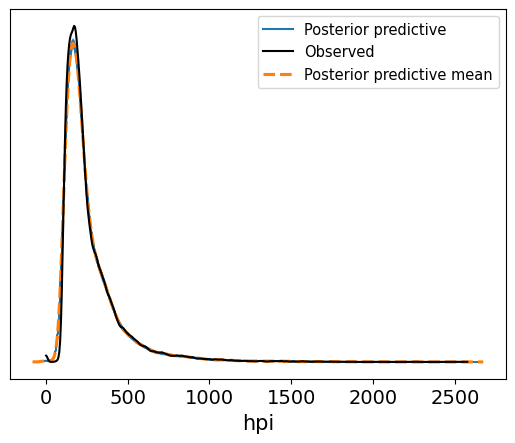

In [88]:
# Posterior predictive check
ppc_preds = model_simple.predict(results_simple, kind="pps", inplace=False)

idata_ppc = results_simple.copy()
idata_ppc.add_groups(posterior_predictive=ppc_preds.posterior_predictive)

az.plot_ppc(idata_ppc, var_names=["hpi"], group="posterior", num_pp_samples=100)


In [90]:
# Create train and test sets
df_train = df_lagged_bayes[df_lagged_bayes["yr"] <= 2019].copy()
df_2020 = df_lagged_bayes[df_lagged_bayes["yr"] == 2020].copy()

# Fit the model for year 2020
model_test = bmb.Model(formula=formula_fe, data=df_train)
results_test = model_test.fit(draws=1000, tune=1000)

# Predict for year 2020
posterior_pred_2020 = model_test.predict(idata=results_test, data=df_2020, kind="pps", inplace=False)
az.summary(results_test, round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, hpi_lag1_scaled, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, deaths_hurricane, injuries_hurricane, damage_hurricane, real_gdp, unemployment_rate, prop_rate, total_home_purchase, total_amt_purchase, total_population]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 103 seconds.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,20.87,0.07,20.75,21.00,0.0,0.0,8176.22,2936.17,1.0
Intercept,268.28,0.09,268.11,268.45,0.0,0.0,9856.02,2644.24,1.0
hpi_lag1_scaled,182.16,0.11,181.95,182.36,0.0,0.0,7069.96,2987.57,1.0
flood_frequency,-0.14,0.09,-0.31,0.03,0.0,0.0,6762.07,2784.48,1.0
flood_property_damage,-0.06,0.09,-0.22,0.11,0.0,0.0,7567.22,2986.81,1.0
flood_duration_hours,-0.27,0.09,-0.44,-0.08,0.0,0.0,8513.09,2913.23,1.0
heat_stress_index,-0.10,0.10,-0.30,0.09,0.0,0.0,6481.74,2917.65,1.0
drought_annual_mean_index,-0.28,0.11,-0.48,-0.08,0.0,0.0,5529.50,3487.90,1.0
fire_frequency,0.60,0.10,0.41,0.78,0.0,0.0,6543.92,2932.01,1.0
fire_size,0.06,0.10,-0.15,0.24,0.0,0.0,8902.60,2646.82,1.0


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


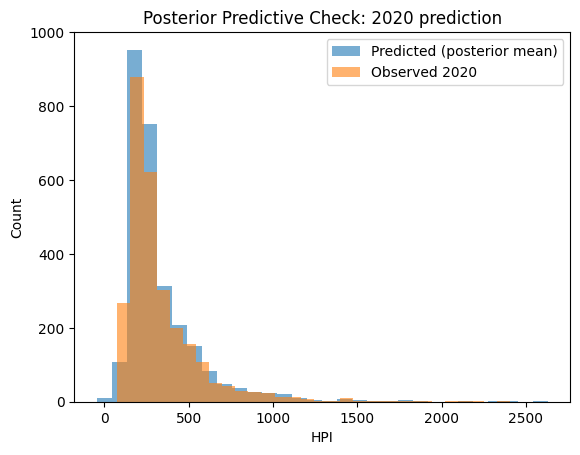

: 

In [104]:
import matplotlib.pyplot as plt

ppc_preds_test = model_test.predict(results_test, data=df_2020, kind="pps", inplace=False)
posterior_preds = ppc_preds_test.posterior_predictive["hpi"]
y_preds_mean_2020 = posterior_preds.mean(dim=["chain", "draw"]).values
y_true_2020 = df_2020["hpi"].values

plt.hist(y_preds_mean_2020, bins=30, alpha=0.6, label="Predicted (posterior mean)")
plt.hist(y_true_2020, bins=30, alpha=0.6, label="Observed 2020")
plt.legend()
plt.title("Posterior Predictive Check: 2020 prediction")
plt.xlabel("HPI")
plt.ylabel("Count")
plt.show()


In [94]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mape = np.mean(np.abs((y_true_2020 - y_preds_mean_2020) / y_true_2020)) * 100
print(f"MAPE: {mape:.2f}%")

mse_2020 = mean_squared_error(y_true_2020, y_preds_mean_2020)
rmse_2020 = np.sqrt(mse_2020)
rmse_relative = rmse_2020 / np.mean(y_true_2020)
print(f"Relative RMSE: {rmse_relative:.2%}")

MAPE: 3.30%
Relative RMSE: 5.78%


In [ ]:
# Random state hierarichical model
formula_hier = "hpi ~ hpi_lag1_scaled + " + " + ".join(climate_financial_vars) + " + (1 | county_fips5)"
model_hier = bmb.Model(formula=formula_hier, data=df_train)
results_hier = model_hier.fit(draws=1000, tune=1000, target_accept=0.95)
az.summary(results_hier, round_to=2)

In [ ]:
ppc_hier = model_hier.predict(results_hier, data=df_2020, kind="pps", inplace=False)
y_pred_hier = ppc_hier.posterior_predictive["hpi"].mean(dim=["chain", "draw"]).values
y_true_2020 = df_2020["hpi"].values

mape_hier = np.mean(np.abs((y_true_2020 - y_pred_hier) / y_true_2020)) * 100
print(f"MAPE: {mape_hier:.2f}%")

mse_2020_hier = mean_squared_error(y_true_2020, y_pred_hier)
rmse_2020_hier = np.sqrt(mse_2020_hier)
rmse_relative_hier = rmse_2020_hier / np.mean(y_true_2020)
print(f"Relative RMSE: {rmse_relative_hier:.2%}")

In [95]:
# Baseline model with only the lagged HPI
model_baseline = bmb.Model("hpi ~ hpi_lag1_scaled", data=df_train)
results_baseline = model_baseline.fit(draws=1000, tune=1000, chains=2)

ppc_baseline = model_baseline.predict(results_baseline, data=df_2020, kind="pps", inplace=False)
y_pred_baseline = ppc_baseline.posterior_predictive["hpi"].mean(dim=["chain", "draw"]).values

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_base = mean_absolute_error(y_true_2020, y_pred_baseline)
r2_base = r2_score(y_true_2020, y_pred_baseline)

print(f"Baseline MAE: {mae_base:.2f}")
print(f"Baseline R²: {r2_base:.4f}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma, Intercept, hpi_lag1_scaled]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 16 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Baseline MAE: 7.06
Baseline R²: 0.9953


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


In [96]:
# Model with only with climate and financial predictors
formula_nolag = "hpi ~ " + " + ".join(climate_financial_vars)
model_nolag = bmb.Model(formula_nolag, data=df_train)
results_nolag = model_nolag.fit(draws=1000, tune=1000)
ppc_nolag = model_nolag.predict(results_nolag, data=df_2020, kind="pps", inplace=False)

y_preds_nolag = ppc_nolag.posterior_predictive["hpi"].mean(dim=["chain", "draw"]).values
r2_nolag = r2_score(y_true_2020, y_preds_nolag)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, deaths_hurricane, injuries_hurricane, damage_hurricane, real_gdp, unemployment_rate, prop_rate, total_home_purchase, total_amt_purchase, total_population]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 67 seconds.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


In [97]:
r2_nolag

0.2618231339464677

In [103]:
climate_vars = [
    "flood_frequency",
    "flood_property_damage",
    "flood_duration_hours",
    "heat_stress_index",
    "drought_annual_mean_index",
    "fire_frequency",
    "fire_size",
    "deaths_hurricane",
    "injuries_hurricane",
    "damage_hurricane"
]

# Model with only with climate predictors
formula_climate = "hpi ~ " + " + ".join(climate_vars)
model_climate = bmb.Model(formula_climate, data=df_train)
results_climate = model_climate.fit(draws=1000, tune=1000, chains=1, cores=1, target_accept=0.95)
ppc_climate = model_climate.predict(results_climate, data=df_2020, kind="pps", inplace=False)

y_preds_climate = ppc_climate.posterior_predictive["hpi"].mean(dim=["chain", "draw"]).values
r2_climate = r2_score(y_true_2020, y_preds_climate)
r2_climate 

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [sigma, Intercept, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, deaths_hurricane, injuries_hurricane, damage_hurricane]


Output()

Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 35 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


0.03397048084156706